In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import pickle

In [2]:
df = pd.read_csv(r'C:\Users\bodhe\Downloads\DS\____Projects_____\ticket_pricing_project\data\cleaned\feature_engineered_ticket_data.csv')
df.shape

(30000, 35)

In [3]:
df.columns

Index(['ticket_id', 'event_id', 'event_name', 'event_date', 'sale_date',
       'days_until_event', 'ticket_price', 'quantity_sold', 'venue_capacity',
       'revenue', 'event_month', 'is_weekend', 'event_quarter',
       'event_day_of_week', 'temperature', 'rain', 'humidity', 'avg_mentions',
       'avg_sentiment_score', 'is_trending', 'event_type_comedy',
       'event_type_concert', 'event_type_festival', 'event_type_sports',
       'event_type_theater', 'seat_section_floor',
       'seat_section_general admission', 'seat_section_lower bowl',
       'seat_section_upper bowl', 'seat_section_vip', 'city_chicago',
       'city_los angeles', 'city_miami', 'city_new york', 'city_seattle'],
      dtype='object')

In [4]:
not_included_cols = ['ticket_id', 'event_id', 'event_name', 'event_date', 'sale_date',
    'ticket_price', 'temperature' , 'humidity' , 'avg_competitor_price' , 'price_vs_competitors' 
    'revenue',       
    'quantity_sold', 
    'cumulative_tickets_sold',
    'tickets_remaining']

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

feature_cols = [col for col in numeric_cols if col not in not_included_cols]

target = 'ticket_price'

In [6]:
X = df[feature_cols].copy()
y = df[target].copy()

In [7]:
missing_values = X.isnull().sum().sum()
if missing_values > 0:
    X.fillna(X.median(), inplace=True)
else:
    print("No missing values found in features.")

No missing values found in features.


In [9]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression MSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R^2:", r2_score(y_test, y_pred_lr))



Linear Regression MSE: 31.380625906170522
Linear Regression R^2: 0.9136177467347589


In [13]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42 , max_depth=10)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest MSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R^2:", r2_score(y_test, y_pred_rf))

Random Forest MSE: 9.876551814307849
Random Forest R^2: 0.9914431874528501


In [17]:
# XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=7, random_state=42 , n_jobs=-1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost MSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("XGBoost R^2:", r2_score(y_test, y_pred_xgb))

XGBoost MSE: 10.08864504059971
XGBoost R^2: 0.9910717362917052


Text(0.5, 1.0, 'Top 20 Feature Importances from Random Forest')

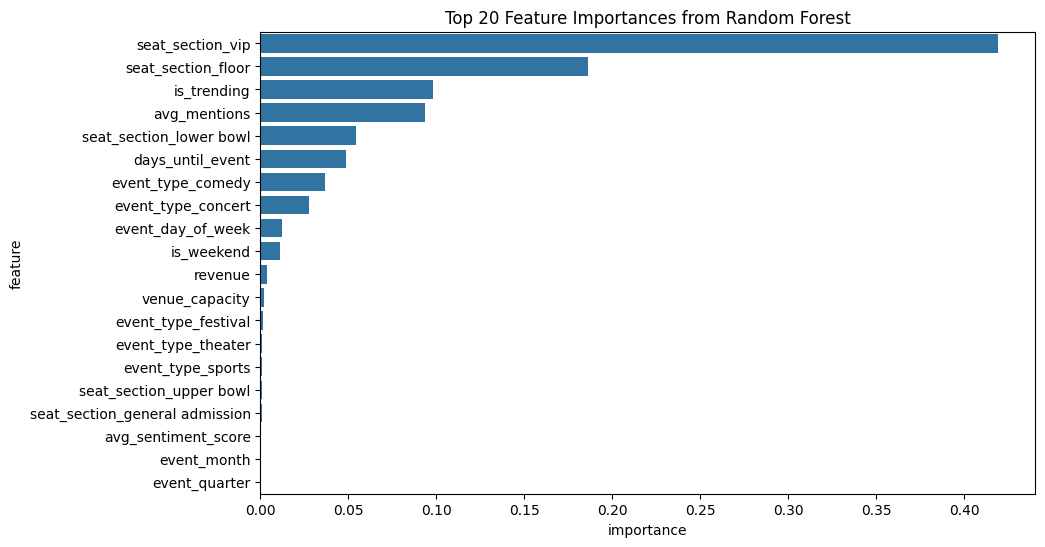

In [18]:
# Feature importance from Random Forest
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feature_importance_df.sort_values(by='importance', ascending=False, inplace=True)
plt.figure(figsize=(10, 6)) 
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances from Random Forest')  

In [23]:
# Save model 
with open(r'C:\Users\bodhe\Downloads\DS\____Projects_____\ticket_pricing_project\models\xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("Model saved successfully.")

with open(r'C:\Users\bodhe\Downloads\DS\____Projects_____\ticket_pricing_project\models\feature_names.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
print("Feature names saved successfully.")

Model saved successfully.
Feature names saved successfully.
